# Actividad Obligatoria: Segmentación de Clientes
**Objetivo:** Aplicar limpieza, PCA y Clustering para identificar perfiles bancarios.

## 1. Tipos de Análisis Exploratorio de Datos
| Tipo de Análisis | Descripción | Ejemplo |
| :--- | :--- | :--- |
| **Análisis Univariado** | Examina una variable a la vez. | Histograma de edades. |
| **Análisis Multivariado** | Analiza relaciones entre múltiples variables. | Correlación Edad vs Ingresos. |

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.DataFrame({
    "Cliente": [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad": [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos": [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Experiencia": [2, 10, 7, 15, 3, 20, 12, 4]
})

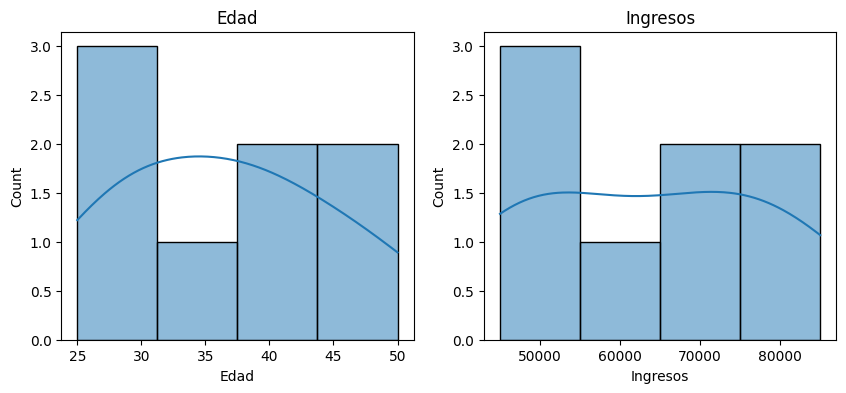

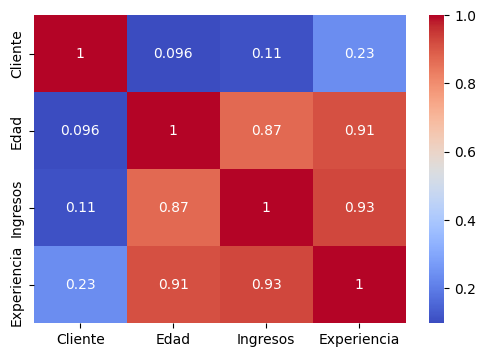

In [2]:
# Gráficos de distribución
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["Edad"], kde=True, ax=axes[0]).set_title("Edad")
sns.histplot(df["Ingresos"], kde=True, ax=axes[1]).set_title("Ingresos")
plt.show()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

## 2. Análisis Univariado
| Técnica | Descripción | Ejemplo |
| :--- | :--- | :--- |
| **Tendencia central** | Media, mediana y moda. | Salario promedio. |
| **Dispersión** | Rango, varianza y desvío. | Variabilidad de edades. |
| **Gráficos** | Histogramas y Boxplots. | Detección de outliers. |

In [3]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])

pca = PCA()
pca.fit(scaled_data)
cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Componentes necesarias para 90% varianza: {np.where(cum_var >= 0.90)[0][0] + 1}")

# Reducción a 2D para visualización
df_pca = pd.DataFrame(PCA(n_components=2).fit_transform(scaled_data), columns=["PC1", "PC2"])

Componentes necesarias para 90% varianza: 1


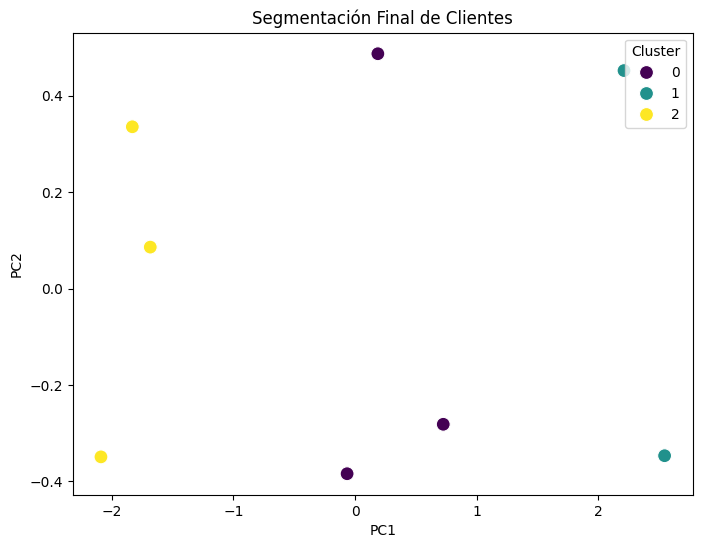

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca["Cluster"] = kmeans.fit_predict(df_pca)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster", palette="viridis", s=100)
plt.title("Segmentación Final de Clientes")
plt.show()

## 3. Uso de LLM y Validación
* **Prompt 1:** Estrategias para segmentación avanzada.
* **Aporte:** Sugerencia de usar Silhouette Score para validar el número de clusters.
* **Reflexión:** El uso de PCA permitió simplificar un dataset con alta correlación, facilitando la visualización de los 3 perfiles de clientes.